# Генеративные нейросети
## Задание 1

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.



**Баллы за задание:**
* Задача 1 — 120 баллов.
* Задача 2 — 100 баллов.

-----------

In [ ]:
# Bot check

# HW_ID: ds_gen1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [ ]:
import os

import numpy as np
import torch
import torchvision.datasets as dset
import torch.nn as nn
import torchvision.transforms as transforms

import torch
import torch.nn as nn
import torch.optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torchsummary import summary
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
from torchvision import models
from torch.nn.utils import spectral_norm
import torch.nn.functional as F

from PIL import Image

import pyro
import pyro.distributions as dist
import pyro.contrib.examples.util
from pyro.infer import SVI, Trace_ELBO
import pyro.optim

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

import seaborn as sns
sns.set(palette='Set2')

from IPython.display import clear_output
from IPython.display import HTML

from tqdm.auto import tqdm

In [ ]:
pyro.enable_validation(True)
pyro.set_rng_seed(0)
np.random.seed(42)

# отключим валидацию аргументов распределений
pyro.distributions.enable_validation(False)

PATH = "/home/udeneev-av/DS_tasks/BS_in_DA/hw_gen1"

device = torch.device("cuda:6" if torch.cuda.is_available() else "cpu")
device

USE_CUDA = torch.cuda.is_available()
USE_CUDA

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована
...

---
### Задача 1.

Ура, картиночки!!! Возьмем два датасета:
* <a href="https://www.kaggle.com/datasets/soumikrakshit/anime-faces">Anime Faces</a>
* <a href="https://www.kaggle.com/datasets/spandan2/cats-faces-64x64-for-generative-models">Cats faces</a>

Оба датасета содержат десятки тысяч изображений размера $64 \times 64$ соответственно аниме-персонажей и котов.

---

**1.** Возьмите любой из этих датасетов и обучите на нем модель VAE-GAN. Визуализируйте процесс обучения в нескольких картинках в виде html, подобно примерам с занятия.

*Указания и рекомендации.*
* Обязательно посмотрите код с занятия. Обращайте внимание на размерности распределений.
* **Любой код с занятий можно использовать без ограничений.**
* Обратите внимание, что данном случае не нужно передавать метки изображений. Кроме того, изображения имеют несколько цветовых каналов.
* Проведите достаточную настройку гиперпараметров: сложность нейросетей, количество итераций обучения, шаг обучения. Посмотрите на выбор гиперпараметров в примерах с занятий.
* Начинайте работу с простых нейросетей на небольшом объеме данных, постепенно усложняйте процесс.
* Сохраняйте удачные запуски и обученные модели (пример в семинаре), чтобы при необходимости вернуться к ним.
* **Если у вас получаются плохие результаты, скорее всего модель обучилась неправильно, или гиперпараметры выбраны неудачно.** Перечитайте еще раз все рекомендации, перепроверьте свое решение. Если не помогло, задайте вопрос в чате.

Не забывайте про:
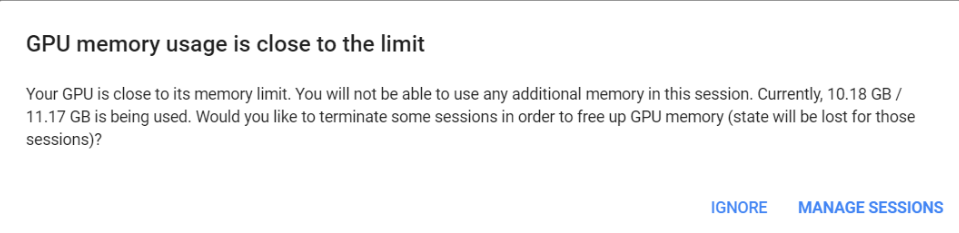


Загрузим датасет anime faces

In [ ]:
def setup_data_loaders(batch_size=128, use_cuda=False, path="./data", max_size=None):
    # Определим трансформации для изображений
    trans = transforms.Compose([
        transforms.ToTensor(),
    ])
    
    full_dataset = datasets.ImageFolder(root=path, transform=trans)

    # Ограничение размера датасета
    if max_size is not None and max_size < len(full_dataset):
        full_dataset, _ = random_split(full_dataset, [max_size, len(full_dataset) - max_size])

    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_set, test_set = random_split(full_dataset, [train_size, test_size])

    kwargs = {'num_workers': 4, 'pin_memory': use_cuda}

    train_loader = DataLoader(dataset=train_set, batch_size=batch_size, shuffle=True, **kwargs)
    test_loader = DataLoader(dataset=test_set, batch_size=batch_size, shuffle=False, **kwargs)

    return train_loader, test_loader

In [ ]:
train_loader, val_loader = setup_data_loaders(256, use_cuda=USE_CUDA, path=PATH + '/data')

Реализацию VAE-GAN возьмем с лекции

In [ ]:
def weights_init(model):
    ''' Инициализация весов генератора и дискриминатора '''
    
    classname = model.__class__.__name__
    
    if classname.find('Conv') != -1:
        nn.init.normal_(model.weight.data, 0.0, 0.02)
        
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(model.weight.data, 1.0, 0.02)
        nn.init.constant_(model.bias.data, 0)

class Reshape(nn.Module):
    def __init__(self, shape):
        super(Reshape, self).__init__()
        self.shape = shape
        
    def forward(self, x):
        return x.view(self.shape)

In [ ]:
class Decoder(nn.Module):
    def __init__(self, y_dim, p=0.0, out_channels=3, marker_dim=0):
        super().__init__()
        self.marker_dim = marker_dim
        in_dim = y_dim + (marker_dim if marker_dim > 0 else 0)

        self.fc = nn.Sequential(
            nn.Linear(in_dim, 512 * 4 * 4),
            nn.ReLU(),
            Reshape((-1, 512, 4, 4))
        )

        self.net = nn.Sequential(
            # 4x4 → 8x8
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # 8x8 → 16x16
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 16x16 → 32x32
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 32x32 → 64x64
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Refinement layer (optional but helpful)
            nn.Conv2d(32, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Output
            nn.Conv2d(32, out_channels, 3, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, y, marker=None):
        if self.marker_dim > 0 and marker is not None:
            if marker.dim() == 1:
                marker = F.one_hot(marker, num_classes=self.marker_dim).float()
            y = torch.cat([y, marker], dim=1)
        x = self.fc(y)
        return self.net(x)

class Encoder(nn.Module):
    def __init__(self, y_dim, p=0.0, in_channels=3, marker_dim=0):
        super().__init__()
        self.marker_dim = marker_dim
        total_in_channels = in_channels + (marker_dim if marker_dim > 0 else 0)

        self.net = nn.Sequential(
            # 64 → 32
            nn.Conv2d(total_in_channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 → 16
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 → 8
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 → 4
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten()
        )

        self.fc_output_loc = nn.Linear(512 * 4 * 4, y_dim)
        self.fc_output_scale = nn.Linear(512 * 4 * 4, y_dim)

    def forward(self, x, marker=None):
        if self.marker_dim > 0 and marker is not None:
            if marker.dim() == 1:
                marker = F.one_hot(marker, num_classes=self.marker_dim).float()
            marker = marker.view(marker.size(0), self.marker_dim, 1, 1)
            marker = marker.expand(-1, -1, x.size(2), x.size(3))
            x = torch.cat([x, marker], dim=1)

        hidden = self.net(x)
        y_loc = self.fc_output_loc(hidden)
        y_scale = torch.exp(self.fc_output_scale(hidden))
        return y_loc, y_scale

In [ ]:
class Encoder(nn.Module):
    def __init__(self, y_dim, p=0.0, in_channels=3, marker_dim=0):
        super().__init__()
        self.marker_dim = marker_dim
        total_in_channels = in_channels + (marker_dim if marker_dim > 0 else 0)

        self.stem = nn.Sequential(
            # 64 → 32
            nn.Conv2d(total_in_channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.block1 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(512, 1024, 4, 2, 1),  # 4x4 → 2x2
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten()
        )

        self.dropout = nn.Dropout(p=p) if p > 0 else nn.Identity()

        # Теперь hidden_dim = 1024 * 2 * 2 = 4096
        self.fc_output_loc = nn.Linear(1024 * 2 * 2, y_dim)
        self.fc_output_scale = nn.Linear(1024 * 2 * 2, y_dim)

    def forward(self, x, marker=None):
        if self.marker_dim > 0 and marker is not None:
            if marker.dim() == 1:
                marker = F.one_hot(marker, num_classes=self.marker_dim).float()
            marker = marker.view(marker.size(0), self.marker_dim, 1, 1)
            marker = marker.expand(-1, -1, x.size(2), x.size(3))
            x = torch.cat([x, marker], dim=1)

        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.dropout(x)

        y_loc = self.fc_output_loc(x)
        y_scale = F.softplus(self.fc_output_scale(x)) + 1e-5
        return y_loc, y_scale

class Decoder(nn.Module):
    def __init__(self, y_dim, p=0.0, out_channels=3, marker_dim=0):
        super().__init__()
        self.marker_dim = marker_dim
        in_dim = y_dim + (marker_dim if marker_dim > 0 else 0)

        # Увеличенная начальная размерность
        self.fc = nn.Sequential(
            nn.Linear(in_dim, 1024 * 2 * 2),
            nn.ReLU(),
            Reshape((-1, 1024, 2, 2))
        )

        self.net = nn.Sequential(
            # 2x2 → 4x4
            nn.ConvTranspose2d(1024, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            # 4x4 → 8x8
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # 8x8 → 16x16
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 16x16 → 32x32
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 32x32 → 64x64
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Refinement stack (2x)
            nn.Conv2d(32, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Output
            nn.Conv2d(32, out_channels, 3, 1, 1),
            nn.Sigmoid()
        )

        self.dropout = nn.Dropout2d(p=p) if p > 0 else nn.Identity()

    def forward(self, y, marker=None):
        if self.marker_dim > 0 and marker is not None:
            if marker.dim() == 1:
                marker = F.one_hot(marker, num_classes=self.marker_dim).float()
            y = torch.cat([y, marker], dim=1)
        x = self.fc(y)
        x = self.dropout(x)
        return self.net(x)

In [ ]:
class Discriminator(nn.Module):
    """Сверточный дискриминатор для изображений 64×64×3 с условием по маркеру (опционально)."""

    def __init__(self, n_channel=3, marker_dim=0, p=0.3):
        """
        n_channel  — число каналов изображения (1 или 3)
        marker_dim — размерность one-hot маркера (0 = безусловный режим)
        p          — dropout probability
        """
        super().__init__()
        self.marker_dim = marker_dim

        # Общий входной канал = C изображения + маркеры
        in_channels = n_channel + marker_dim if marker_dim > 0 else n_channel

        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),  # 64×64 → 32×32
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(p=p),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),          # 32×32 → 16×16
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(p=p),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),         # 16×16 → 8×8
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(p=p),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),         # 8×8 → 4×4
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),  # 512 * 4 * 4 = 8192

            nn.Dropout(p=p),
            nn.Linear(512 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, x, marker=None):
        """
        x      — изображение (B, C, H, W)
        marker — целые индексы (B,) или one-hot (B, marker_dim); можно None
        """
        if self.marker_dim > 0 and marker is not None:
            if marker.dim() == 1:  # индексы → one-hot
                marker = F.one_hot(marker, num_classes=self.marker_dim).float()
            marker = marker.view(marker.size(0), self.marker_dim, 1, 1)
            marker = marker.expand(-1, -1, x.size(2), x.size(3))
            x = torch.cat([x, marker], dim=1)

        return self.layers(x)


In [ ]:
class CVAE_GAN(nn.Module):
    def __init__(self, y_dim=2, marker_dim=10, p=0.1, use_cuda=True, device='cpu'):
        super().__init__()

        # ==== Лёгкие модели ====
        self.encoder_ = Encoder(y_dim, marker_dim=marker_dim, p=p)
        self.decoder_ = Decoder(y_dim, marker_dim=marker_dim, p=p)
        self.discriminator_ = Discriminator(n_channel=3, marker_dim=marker_dim, p=0.5)

        # ==== Устройства ====
        self.device = device
        self.use_cuda = use_cuda
        self.y_dim = y_dim
        self.marker_dim = marker_dim
        self.to(self.device)

    # ---------------- GUIDES ----------------
    def guide(self, x, markers=None):
        x = x.to(self.device)
        if markers is not None:
            markers = markers.to(self.device)

        pyro.module("encoder", self.encoder_)
        with pyro.plate("data", x.shape[0]):
            y_loc, y_scale = self.encoder_(x, markers)
            pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))

    def guide_generate(self, batch_size):
        # Генератор ненаблюдаемых переменных — пусто
        pass

    # ---------------- MODELS ----------------
    def model(self, x, markers=None):
        x = x.to(self.device)
        if markers is not None:
            markers = markers.to(self.device)

        pyro.module("decoder", self.decoder_)
        with pyro.plate("data", x.shape[0]):
            y_loc = torch.zeros((x.shape[0], self.y_dim), device=self.device)
            y_scale = torch.ones((x.shape[0], self.y_dim), device=self.device)
            y = pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))

            loc_img = self.decoder_(y, markers)
            pyro.sample("obs", dist.Bernoulli(loc_img).to_event(3), obs=x)

    def model_generate(self, batch_size):
        pyro.module("decoder", self.decoder_)
        with pyro.plate("data", batch_size):
            y_loc = torch.zeros((batch_size, self.y_dim), device=self.device)
            y_scale = torch.ones((batch_size, self.y_dim), device=self.device)
            y = dist.Normal(y_loc, y_scale).rsample()

            rand_markers = None
            if self.marker_dim > 0:
                rand_markers = torch.randint(0, self.marker_dim, (batch_size,), device=self.device)

            loc_img = self.decoder_(y, rand_markers)
            pyro.sample("obs", dist.Bernoulli(loc_img).to_event(3))

    # ---------------- WRAPPERS ----------------
    def encoder(self, x, markers=None, return_cpu=True):
        x = x.to(self.device)
        if isinstance(markers, torch.Tensor):
            markers = markers.to(self.device)

        y_loc, y_scale = self.encoder_(x, markers)
        if return_cpu:
            return y_loc.cpu(), y_scale.cpu()
        return y_loc, y_scale

    def decoder(self, y, markers=None, return_cpu=False):
        y = y.to(self.device)
        if isinstance(markers, torch.Tensor):
            markers = markers.to(self.device)

        loc_img = self.decoder_(y, markers)
        if return_cpu:
            loc_img = loc_img.cpu()
        return loc_img

    def reconstruct_img(self, x, markers=None, return_cpu=True):
        x = x.to(self.device)
        if isinstance(markers, torch.Tensor):
            markers = markers.to(self.device)

        y_loc, y_scale = self.encoder_(x, markers)
        y = dist.Normal(y_loc, y_scale).rsample()
        loc_img = self.decoder_(y, markers)
        if return_cpu:
            loc_img = loc_img.cpu()
        return loc_img


In [ ]:
def train_discriminator(model, optimizer, criterion, real_batch, z_dim=None, real_markers=None):
    model.discriminator_.train(True)
    model.discriminator_.zero_grad()
    batch_size = real_batch.size(0)
    device = real_batch.device
    real_label, fake_label = 0.9, 0.1

    z_dim = model.y_dim if z_dim is None else z_dim

    # ===== Реальные изображения =====
    label_real = torch.full((batch_size,), real_label, device=device)
    output_real = model.discriminator_(real_batch, real_markers).view(-1)

    # ===== Восстановленные изображения =====
    y_loc, y_scale = model.encoder_(real_batch, real_markers)
    y_sample = dist.Normal(y_loc, y_scale).rsample()
    reconstructed = model.decoder_(y_sample, real_markers)
    label_recon = torch.full((batch_size,), fake_label, device=device)
    output_recon = model.discriminator_(reconstructed, real_markers).view(-1)

    # ==== сгенерированные ====
    noise = torch.randn(batch_size, z_dim, device=device)
    if model.marker_dim > 0:
        rand_markers = torch.randint(0, model.marker_dim, (batch_size,), device=device)
        fake_batch = model.decoder_(noise, rand_markers)
        output_fake = model.discriminator_(fake_batch, rand_markers).view(-1)
    else:
        fake_batch = model.decoder_(noise)
        output_fake = model.discriminator_(fake_batch).view(-1)
    label_fake_gen = torch.full((batch_size,), fake_label, device=device)

    total_loss = (criterion(output_real, label_real) +
                  criterion(output_recon, label_recon) +
                  criterion(output_fake, label_fake_gen))
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.discriminator_.parameters(), max_norm=1.0)
    optimizer.step()

    mean_real = output_real.mean().item()
    mean_predicted = output_recon.mean().item()
    mean_fake = output_fake.mean().item()

    return total_loss.item(), mean_real, mean_predicted, mean_fake


In [ ]:
def train_vae(model, svi_vae, svi_generator, real_batch, real_markers=None):
    """
    Одно обновление генератора/энкодера с Pyro.
    Все вычисления на GPU, один вызов backward внутри svi.step.
    """
    model.discriminator_.train(False)
    model.encoder_.zero_grad()
    model.decoder_.zero_grad()

    # Переносим данные на GPU
    device = next(model.parameters()).device
    real_batch = real_batch.to(device, non_blocking=True)
    if real_markers is not None:
        real_markers = real_markers.to(device, non_blocking=True)

    elbo1 = -svi_vae.step(real_batch, real_markers)
    elbo2 = -svi_generator.step(real_batch.shape[0])
    
    return (elbo1 + elbo2)

In [ ]:
def callback(
    losses_elbo, 
    losses_discriminator, 
    D_real_means, 
    D_fake_means, 
    DG_fake_means, 
    it
):
    '''
    Отрисовка текущего статуса обучения.
    losses_elbo -- значение лосса энкодера и декодера/генератора по итерациям
    losses_discriminator -- значение лосса дискриминатора по итерациям
    D_real_means -- среднее значение дискриминатора на реальных объектах по итерациям
    D_fake_means -- среднее значение дискриминатора на сгенерированных объектах по итерациям
    DG_fake_means -- среднее значение дискриминатора на сгенерированных объектах 
                     по итерациям после обучения генератора
    it -- номер итерации
    '''

    # Отложенная очистка экрана
    clear_output(wait=True)
    
    # Объявление фигуры и сетки
    plt.figure(figsize=(20, 5), constrained_layout=False)
    plt.suptitle(f'Итерация {it}', y=1.02)
    plt.subplot(131)
    plt.plot(losses_discriminator, lw=2, label='дискр.')
    plt.title('BCELoss')
    plt.legend()
    plt.xlabel('Номер итерации')
    plt.subplot(132)
    plt.plot(losses_generator, lw=2, label='VAE')
    plt.title('ELBO')
    plt.legend()
    plt.xlabel('Номер итерации')
    plt.subplot(133)
    plt.plot(D_real_means, lw=2, label='реальные', alpha=0.7)
    plt.plot(D_fake_means, lw=2, label='сгенер.', alpha=0.7)
    plt.plot(DG_fake_means, lw=2, label='восст.', alpha=0.7)
    plt.title('Среднее значение выхода дискриминатора')
    plt.ylabel('Вероятность истинности картинки')
    plt.xlabel('Номер итерации')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
batch_size = 256 
real_label = 1.
fake_label = 0.

In [ ]:
z_dim = 128  # размерность случайного вектора
num_iter = 2001  # Количество итераций обучения
n_iter_generator = 3  # Количество итераций обучения генератора в одной общей итерации
n_iter_discriminator = 1  # Количество итераций обучения дискриминатора в одной общей итерации
callback_frequency = 100  # Частота обновления графика
picture_save_frequency = 500  # Частота сохранения визуализации текущей генерации

# Очищаем хранилище параметров
pyro.clear_param_store()

# === Модель CVAE без маркеров ===
vae = CVAE_GAN(y_dim=z_dim, marker_dim=0, p=0.2, use_cuda=USE_CUDA, device=device)
vae.encoder_.apply(weights_init)
vae.decoder_.apply(weights_init)
vae.discriminator_.apply(weights_init)

# === Фиксированный батч латентных векторов для визуализации ===
fixed_noise = torch.randn(batch_size, z_dim, device=device)

# === Оптимизаторы ===
lr = 0.0003  # learning rate
lr_D = 0.00001  # learning rate
beta1 = 0.5  # гиперпараметр оптимизатора Adam 
criterion = nn.BCELoss()  # Лосс

# Вариационный вывод для обучения автоэнкодера (encoder + decoder)
optimizer_vae = pyro.optim.Adam({"lr": lr, "betas": (beta1, 0.999)})
svi_vae = SVI(vae.model, vae.guide, optimizer_vae, loss=Trace_ELBO())

# Вариационный вывод для обучения генератора (decoder)
optimizer_generator = pyro.optim.Adam({"lr": lr, "betas": (beta1, 0.999)})
svi_generator = SVI(vae.model_generate, vae.guide_generate, optimizer_generator, loss=Trace_ELBO())

# Оптимизатор для дискриминатора (обучается отдельно вручную)
optim_discriminator = torch.optim.Adam(
    vae.discriminator_.parameters(), lr=lr_D, betas=(beta1, 0.999)
)

In [ ]:
# Итератор для DataLoader
train_iter = iter(train_loader)

# Списки для логов
img_list = []
losses_generator = []
losses_discriminator = []
D_real_means, D_fake_means, DG_fake_means = [], [], []

for it in tqdm(range(num_iter), desc="Training"):

    # === Обучаем дискриминатор ===
    for _ in range(n_iter_discriminator):
        try:
            real_batch, real_markers = next(train_iter)  # <<-- используем обе переменные!
        except StopIteration:
            train_iter = iter(train_loader)
            real_batch, real_markers = next(train_iter)
        real_batch = real_batch.to(device, non_blocking=True)
        real_markers = real_markers.to(device, non_blocking=True)
        
        return_discr = train_discriminator(
            vae, 
            optim_discriminator, 
            criterion, 
            real_batch,
            z_dim,
            real_markers=real_markers,      # <<--- передаем explicit
        )

    # === Обучаем энкодер и декодер/генератор ===
    for _ in range(n_iter_generator):
        try:
            real_batch, real_markers = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            real_batch, real_markers = next(train_iter)
        real_batch = real_batch.to(device, non_blocking=True)
        real_markers = real_markers.to(device, non_blocking=True)

        return_vae = train_vae(
            vae, 
            svi_vae,
            svi_generator,
            real_batch,
            real_markers,
        )

    # === Логи ===
    losses_generator.append(return_vae)
    losses_discriminator.append(return_discr[0])
    D_real_means.append(return_discr[1])
    D_fake_means.append(return_discr[3])
    DG_fake_means.append(return_discr[2])

    # === Визуализация каждые callback_frequency итераций ===
    if it % callback_frequency == 0:
        callback(losses_generator, losses_discriminator, D_real_means, 
                 D_fake_means, DG_fake_means, it)

    if (it % picture_save_frequency == 0) or (it == num_iter - 1):
        with torch.no_grad():
            # fixed_noise заранее инициализирован: torch.randn(batch_size, z_dim, device=device)
            fake = vae.decoder(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, nrow=16, padding=2, normalize=True))

In [ ]:
# Извлечем батч реальных изображений
real_batch = next(iter(train_loader))

# Рисуем реальные изображения
plt.figure(figsize=(20, 11))
plt.subplot(121)
plt.axis("off")
plt.title("Реальные изображения")
plt.imshow(np.transpose(vutils.make_grid(
    real_batch[0].to(device)[:256], nrow=16, padding=5, normalize=True
).cpu(), (1,2,0)))

# Рисуем сгенерированные изображения
plt.subplot(122)
plt.axis("off")
plt.title("Сгенерированные изображения")
plt.imshow(np.transpose(img_list[-1], (1,2,0)))
plt.show()

In [ ]:
# # Чтобы сохранить большую анимацию
# import matplotlib
# matplotlib.rcParams['animation.embed_limit'] = 2**128

# fig = plt.figure(figsize=(12, 12))
# plt.axis("off")
# # Отображаем каждую картинку отельно
# ims = [[plt.imshow(np.transpose(i, (1,2,0)), animated=True)] for i in img_list]
# ani = animation.ArtistAnimation(fig, ims, interval=500, blit=True)
# plt.show()
# clear_output()  # Уберем саму фигуру matplotlib

# # Сохраняем html
# folder="tmp_folder/"
# os.makedirs(folder, exist_ok=True)
# html = ani.to_jshtml()
# with open(folder+'vae_gan_training_animation.html', 'w') as f:
#     f.writelines(html)

# # Визуализируем html
# HTML(html)

**2.** Оцените визуально реалистичность сгенерированных изображений из случайного шума. Также оцените визуально качество реконструкции изображений.

Сгенерированные сообщение получились немного размытыми, но основные детали вполне различимы, вроде волос, глаз, черт лица.

Посмотрим на несколько примеров восстановленных изображений

In [ ]:
tmp_images = next(iter(val_loader))[0][:25].to(vae.device)
y_loc, y_scale = vae.encoder(tmp_images, return_cpu=False)
y = torch.distributions.Normal(y_loc, y_scale).rsample()
restored = vae.decoder(y, return_cpu=True).detach().numpy()

print(restored.shape)

In [ ]:
real_images = tmp_images.cpu().detach().numpy()

def to_img(x):
    x = np.transpose(x, (1, 2, 0))
    return np.clip(x, 0, 1)

fig, axs = plt.subplots(5, 10, figsize=(20, 10))

for i in range(5):
    for j in range(5):
        idx = i * 5 + j
        axs[i, j].imshow(to_img(real_images[idx]))
        axs[i, j].axis("off")
        axs[i, j + 5].imshow(to_img(restored[idx]))
        axs[i, j + 5].axis("off")

axs[0, 2].set_title('Real')
axs[0, 7].set_title('Restored')

plt.tight_layout()
plt.show()

Как видим, основные черты модель передает, хоть и четкости явно не хватает.

**3.** Выберите два изображения и выполните трансформацию из одного в другое с помощью линейного преобразования в латентном пространстве. Иначе говоря, получите для этих изображений латентное представление с помощью энкодера, проведите между ними отрезок в латентном пространстве, декодируйте этот отрезок в исходное пространство.

In [ ]:
alphas = np.linspace(0, 1, 10)

img_1 = torch.tensor(real_images[6]).to(device)
img_2 = torch.tensor(real_images[15]).to(device)
img_1_loc, img_1_scale = vae.encoder(img_1.unsqueeze(0))
img_2_loc, img_2_scale = vae.encoder(img_2.unsqueeze(0))

transformed_imgs = []
for alpha in alphas:
    tmp_loc = alpha * img_1_loc + (1 - alpha) * img_2_loc
    tmp_scale = alpha * img_1_scale + (1 - alpha) * img_2_scale
    y = torch.distributions.Normal(tmp_loc, tmp_scale).rsample()
    img = vae.decoder(y, return_cpu=True).detach().cpu().numpy()[0]
    transformed_imgs.append(img)

fig, axs = plt.subplots(1, len(transformed_imgs), figsize=(18, 2))

for i, img in enumerate(transformed_imgs):
    axs[i].imshow(to_img(img))
    axs[i].axis("off")
    axs[i].set_title(f"{alphas[i]:.2f}")

plt.tight_layout()
plt.show()


как видим, стиль плавно перетекает из одного изображения в другое.

**4.** Обучите Conditional VAE-GAN на двух датасетах сразу, используя бинарную метку (cat/anime). Оцените визуально качество полученной сети.

In [ ]:
class SimpleImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


def setup_dual_data_loaders(
    cat_path,
    anime_path,
    batch_size=128,
    use_cuda=False,
    max_size=None,
    cat_marker=0,
    anime_marker=1,
):
    trans = transforms.Compose(
        [
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
        ]
    )

    # Собираем картинки и метки
    def gather_paths_labels(path, marker):
        valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        imgs = [
            os.path.join(path, fname)
            for fname in os.listdir(path)
            if fname.lower().endswith(valid_ext)
        ]
        labels = [marker] * len(imgs)
        return imgs, labels

    cat_imgs, cat_labels = gather_paths_labels(cat_path, cat_marker)
    anime_imgs, anime_labels = gather_paths_labels(anime_path, anime_marker)

    all_imgs = cat_imgs + anime_imgs
    all_labels = cat_labels + anime_labels

    if max_size is not None and max_size < len(all_imgs):
        from random import sample

        idxs = sample(range(len(all_imgs)), max_size)
        all_imgs = [all_imgs[i] for i in idxs]
        all_labels = [all_labels[i] for i in idxs]

    full_dataset = SimpleImageDataset(all_imgs, all_labels, transform=trans)

    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_set, test_set = random_split(full_dataset, [train_size, test_size])

    kwargs = {"num_workers": 4, "pin_memory": use_cuda}

    train_loader = DataLoader(
        dataset=train_set, batch_size=batch_size, shuffle=True, **kwargs
    )
    test_loader = DataLoader(
        dataset=test_set, batch_size=batch_size, shuffle=False, **kwargs
    )

    return train_loader, test_loader


train_loader, val_loader = setup_dual_data_loaders("cats", "data", batch_size=256)

In [ ]:
z_dim = 128  # размерность случайного вектора
num_iter = 2001  # Количество итераций обучения
n_iter_generator = 3  # Количество итераций обучения генератора в одной общей итерации
n_iter_discriminator = 1  # Количество итераций обучения дискриминатора в одной общей итерации
callback_frequency = 100  # Частота обновления графика
picture_save_frequency = 500  # Частота сохранения визуализации текущей генерации
marker_dim = 2  # Размерность маркера

# Очищаем хранилище параметров
pyro.clear_param_store()

# === Модель CVAE без маркеров ===
vae = CVAE_GAN(y_dim=z_dim, marker_dim=marker_dim, p=0.2, use_cuda=USE_CUDA, device=device)
vae.encoder_.apply(weights_init)
vae.decoder_.apply(weights_init)
vae.discriminator_.apply(weights_init)

# === Фиксированный батч латентных векторов для визуализации ===
fixed_noise = torch.randn(batch_size, z_dim, device=device)

# === Оптимизаторы ===
lr = 0.0003  # learning rate
lr_D = 0.00001  # learning rate
beta1 = 0.5  # гиперпараметр оптимизатора Adam 
criterion = nn.BCELoss()  # Лосс

# Вариационный вывод для обучения автоэнкодера (encoder + decoder)
optimizer_vae = pyro.optim.Adam({"lr": lr, "betas": (beta1, 0.999)})
svi_vae = SVI(vae.model, vae.guide, optimizer_vae, loss=Trace_ELBO())

# Вариационный вывод для обучения генератора (decoder)
optimizer_generator = pyro.optim.Adam({"lr": lr, "betas": (beta1, 0.999)})
svi_generator = SVI(vae.model_generate, vae.guide_generate, optimizer_generator, loss=Trace_ELBO())

# Оптимизатор для дискриминатора (обучается отдельно вручную)
optim_discriminator = torch.optim.Adam(
    vae.discriminator_.parameters(), lr=lr_D, betas=(beta1, 0.999)
)

In [ ]:
# Итератор для DataLoader
train_iter = iter(train_loader)

# Списки для логов
img_list = []
losses_generator = []
losses_discriminator = []
D_real_means, D_fake_means, DG_fake_means = [], [], []

for it in tqdm(range(num_iter), desc="Training"):
    try:
        real_batch, real_markers = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        real_batch, real_markers = next(train_iter)
    real_batch = real_batch.to(device, non_blocking=True)
    real_markers = real_markers.to(device, non_blocking=True)

    # === Обучаем дискриминатор ===
    for _ in range(n_iter_discriminator):
        return_discr = train_discriminator(
            vae, 
            optim_discriminator, 
            criterion, 
            real_batch,
            z_dim,
            real_markers=real_markers
        )

    # === Обучаем энкодер и декодер/генератор ===
    for _ in range(n_iter_generator):
        return_vae = train_vae(
            vae, 
            svi_vae,
            svi_generator,
            real_batch,
            real_markers=real_markers,
        )

    # === Логи ===
    losses_generator.append(return_vae)
    losses_discriminator.append(return_discr[0])
    D_real_means.append(return_discr[1])
    D_fake_means.append(return_discr[3])
    DG_fake_means.append(return_discr[2])

    # === Визуализация каждые callback_frequency итераций ===
    if it % callback_frequency == 0:
        callback(losses_generator, losses_discriminator, D_real_means, 
                 D_fake_means, DG_fake_means, it)
    
    if (it % picture_save_frequency == 0) or (it == num_iter - 1):
        with torch.no_grad():
            fake = vae.decoder(fixed_noise, markers=real_markers).detach().cpu()
            img_list.append(vutils.make_grid(fake, nrow=16, padding=2, normalize=True))

In [ ]:
# Извлечем батч реальных изображений
real_batch = next(iter(train_loader))

# Рисуем реальные изображения
plt.figure(figsize=(20, 11))
plt.subplot(121)
plt.axis("off")
plt.title("Реальные изображения")
plt.imshow(np.transpose(vutils.make_grid(
    real_batch[0].to(device)[:256], nrow=16, padding=5, normalize=True
).cpu(), (1,2,0)))

# Рисуем сгенерированные изображения
plt.subplot(122)
plt.axis("off")
plt.title("Сгенерированные изображения")
plt.imshow(np.transpose(img_list[-1], (1,2,0)))
plt.show()

Выполните трансфер стиля: из котика создайте аниме-персонажа и наоборот.

In [ ]:
cat_img, cat_marker, cat_idx = None, None, None
for tmp_images, tmp_markers in val_loader:
    real_images = tmp_images.cpu().detach().numpy()
    real_markers = tmp_markers.cpu().detach().numpy()
    cat_idxs = [i for i, m in enumerate(real_markers) if m == 0]
    if cat_idxs:
        cat_idx = cat_idxs[0]
        cat_img = torch.tensor(real_images[cat_idx]).to(device)
        cat_marker = torch.tensor([0], device=device)
        break

anime_img, anime_marker, anime_idx = None, None, None
for tmp_images, tmp_markers in val_loader:
    real_images = tmp_images.cpu().detach().numpy()
    real_markers = tmp_markers.cpu().detach().numpy()
    anime_idxs = [i for i, m in enumerate(real_markers) if m == 1]
    if anime_idxs:
        anime_idx = anime_idxs[1]
        anime_img = torch.tensor(real_images[anime_idx]).to(device)
        anime_marker = torch.tensor([1], device=device)
        break


alphas = np.linspace(0, 1, 10)
img_cat = torch.tensor(real_images[cat_idx]).to(device)
img_anime = torch.tensor(real_images[anime_idx]).to(device)

marker_cat = torch.tensor([0], device=device)
marker_anime = torch.tensor([1], device=device)

img_cat_loc, img_cat_scale = vae.encoder(img_cat.unsqueeze(0), marker_cat)
img_anime_loc, img_anime_scale = vae.encoder(img_anime.unsqueeze(0), marker_anime)

transformed_imgs = []

for alpha in alphas:
    tmp_loc = alpha * img_cat_loc + (1 - alpha) * img_anime_loc
    tmp_scale = alpha * img_cat_scale + (1 - alpha) * img_anime_scale
    y = torch.distributions.Normal(tmp_loc, tmp_scale).rsample()
    interp_marker = marker_cat if alpha > 0.5 else marker_anime
    img = vae.decoder(y, interp_marker, return_cpu=True).detach().cpu().numpy()[0]
    transformed_imgs.append(img)

fig, axs = plt.subplots(2, len(transformed_imgs), figsize=(18, 4))

for i, img in enumerate(transformed_imgs):
    axs[0, i].imshow(to_img(img))
    axs[0, i].axis("off")
    axs[0, i].set_title(f"{alphas[i]:.2f}")
    
real_cat = to_img(img_cat.cpu().numpy())
real_anime = to_img(img_anime.cpu().numpy())
for i in range(len(transformed_imgs)):
    if i == 0:
        axs[1, i].imshow(real_anime)
        axs[1, i].set_title("REAL anime")
        axs[1, i].axis("off")
    elif i == len(transformed_imgs) - 1:
        axs[1, i].imshow(real_cat)
        axs[1, i].set_title("REAL cat")
        axs[1, i].axis("off")
    else:
        axs[1, i].axis("off")

plt.tight_layout()
plt.show()

**Выводы:**

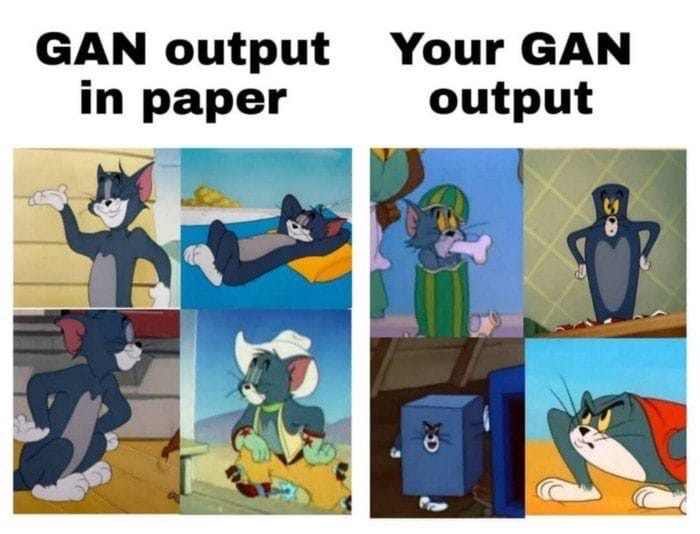

In [ ]:
from sklearn.datasets import make_blobs
from matplotlib.gridspec import GridSpec

---
### Задача 2.

В данном задаче поисследуем GAN'ы на простых примерах и сравним их с VAE.

Для начала вспомним, какую основную задачу решают генеративные модели:

**Ответ:** ...

Для исследований рассмотрим следующий датасет. Идея этого датасета в том, что он состоит из двух частей, в каждой из которых имеется несколько мод.

In [ ]:
data1 = make_blobs(
    n_samples=10000, centers=5, cluster_std=0.5, random_state=10
)[0]
data2 = 30+5*make_blobs(
    n_samples=5000, centers=2, cluster_std=0.5, random_state=20
)[0]
data = np.vstack([data1, data2])

plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1]);

Приступим. Ниже приведены некоторые вспомогательные функции для отрисовки графиков.

In [ ]:
def make_grid(real_data, generated_data, step=0.5):
    '''
    Создание сетки определяемоый границами данных.
    '''    
    
    xmin = min(generated_data[:, 0].min(), real_data[:, 0].min()).numpy()
    xmax = max(generated_data[:, 0].max(), real_data[:, 0].max()).numpy()
    ymin = min(generated_data[:, 1].min(), real_data[:, 1].min()).numpy()
    ymax = max(generated_data[:, 1].max(), real_data[:, 1].max()).numpy()
    
    xdelta = xmax - xmin
    ydelta = ymax - ymin
    xmin, xmax = xmin - 0.2*xdelta, xmax + 0.2*xdelta
    ymin, ymax = ymin - 0.2*ydelta, ymax + 0.2*ydelta

    X, Y = np.mgrid[xmin:xmax:step, ymin:ymax:step]

    return X, Y


def make_grid_predict(discriminator, X, Y):
    '''
    Получение выхода дискриминатора по сетке.
    '''
    
    XY2 = torch.Tensor(np.vstack([X.ravel(), Y.ravel()]).T)
    P = discriminator(XY2).detach().numpy().reshape(X.shape)
    return P


def callback(
    real_data,
    generated_data,
    grid_X,
    grid_Y,
    grid_pred,
    losses_generator, 
    losses_discriminator, 
    D_real_means, 
    D_fake_means, 
    DG_fake_means, 
    it,
    file_name_prefix=None,
):
    '''
    Отрисовка текущего статуса обучения.
    real_data -- обучающие данные
    generated_data -- данные, сгенерированные генератором
    grid_X -- сетка значений X для визуализации
    grid_Y -- сетка значений Y для визуализации
    grid_pred -- сетка значений выходов дискриминатора для визуализации
    losses_generator -- значение лосса генератора по итерациям
    losses_discriminator -- значение лосса дискриминатора по итерациям
    D_real_means -- среднее значение дискриминатора на реальных объектах по итерациям
    D_fake_means -- среднее значение дискриминатора на сгенерированных объектах по итерациям
    DG_fake_means -- среднее значение дискриминатора на сгенерированных объектах 
                     по итерациям после обучения генератора
    it -- номер итерации
    file_name_prefix -- префикс имени файла для сохранения графика
    '''

    # Отложенная очистка экрана
    clear_output(wait=True)
    
    # Объявление фигуры и сетки
    fig = plt.figure(figsize=(16, 16), constrained_layout=False)
    gs = GridSpec(3, 2)
    fig.suptitle(f'Итерация {it}', fontsize=24)
    
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(losses_generator, lw=2, label='генератор', alpha=0.7)
    ax.plot(losses_discriminator, lw=2, label='дискр.', alpha=0.7)
    ax.set_title('Лоссы (BCELoss)')
    ax.legend()
    ax.set_xlabel('Номер итерации')
    
    ax = fig.add_subplot(gs[0, 1])
    ax.plot(D_real_means, lw=2, label='реальные', alpha=0.7)
    ax.plot(D_fake_means, lw=2, label='сгенер.', alpha=0.7)
    ax.plot(DG_fake_means, lw=2, label='сгенер. после\nдообуч. генер.', alpha=0.7)
    ax.set_title('Среднее значение выхода дискриминатора')
    ax.set_ylabel('Вер-ть real')
    ax.set_xlabel('Номер итерации')
    ax.legend()
    
    ax = fig.add_subplot(gs[1:, :])
    ax.pcolormesh(grid_X, grid_Y, grid_pred, cmap='Greens', shading='auto')
    ax.scatter(real_data[:, 0], real_data[:, 1], alpha=0.3, label='Данные')
    ax.scatter(generated_data[:, 0], generated_data[:, 1], alpha=0.3, label='Тек. генерация')
    ax.set_title('Выход декодера, темный цвет соответствует real')
    ax.legend()
    
    plt.tight_layout()
    
    # Сохранение в файл
    if file_name_prefix is not None:
        plt.savefig(f'{file_name_prefix}_{it}.png')
    
    plt.show()

Далее приведен шаблон кода пайплайна обучения GAN, в котором прописаны вызовы функций для отрисовки информационных графиков на некоторых итерациях.

Обратите внимание
* на процесс обучения GAN с занятия, данный шаблон во многом его копирует,
* на реализацию нейросетей из предыдущего домашнего задания по VAE.

Данный код сохраняет графики текущей информации об обучении в виде файлов на каждой итерации. Это позволяет запустить обучение в фоне, и позже посмотреть на него. Сохранение графиков можно отключить, убрав аргумент `file_name_prefix`. При желании вы можете переписать процесс сохранения графиков в html.

Можно также настраивать частоту сохранения графиков с помощью переменной `callback_frequency`.

In [ ]:
# Трассировка обучения
img_list = []
losses_generator = []
losses_discriminator = []
D_real_means, D_fake_means, DG_fake_means = [], [],  []

# Фиксируем набор значений в латентном пространстве, 
# которые будем визуализировать в процессе обучения
noise_to_pic = torch.randn(2000, z_dim, device=device)

for it in range(num_iter):
    
    # Обучаем дискриминатор
    # ...
    
    # Обучаем генератор
    # ...
        
        
    # Сохраняем значения для визуализации трассировки
    losses_generator.append(return_generator[0].item())
    losses_discriminator.append(return_discr[0].item())
    D_real_means.append(return_discr[1])
    D_fake_means.append(return_discr[2])
    DG_fake_means.append(return_generator[1])
        
    # Визуализация
    if it % callback_frequency == 0:
        
        # Получим выборку по выходу генератора
        generated_data = generator(noise_to_pic).detach()
        
        # Получим выход дискриминатора для сетки
        grid_X, grid_Y = make_grid(data, generated_data)
        grid_pred = make_grid_predict(discriminator, grid_X, grid_Y)
        
        callback(
            data, generated_data, grid_X, grid_Y, grid_pred, 
            losses_generator, losses_discriminator, 
            D_real_means, D_fake_means, DG_fake_means, 
            it, file_name_prefix='test'
        )


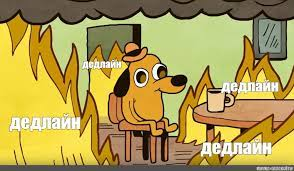

Рассмотрим латентное пространство размерности 5.

Исследуйте работу моделей GAN в следующих случаях:
* сильный дискриминатор, слабый генератор;
* слабый дискриминатор, сильный генератор;
* равновесие (попробуйте этого добиться).

Что можно менять:
* количество и размеры слоев;
* количество шагов генератора и дикриминатора на одну итерацию.

Как соотносится выход генератора с предсказанием дискриминатора?

Ислледуйте разницу следующих подходов к dropout в генераторе:
* слоев dropout нет;
* слои dropout есть, но включены только при обучении;
* слои dropout есть, включены всегда.

Какой подход не следует использовать?

Повторите процесс для одномерного латентного пространства.

Обучите на данных VAE, сравните результаты. Попробуйте использовать разные размеры латентного пространства.

**Выводы:**

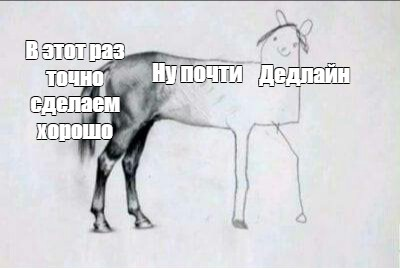

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока